# Raster Agent DEM Workflow

This notebook demonstrates a streaming GAS workflow focused on the `raster_agent`.

Workflow:

1. Download DEM data for Centre County, Pennsylvania using `geospatial_data_retrieval_agent` and OpenTopography.
2. Use `raster_agent` to run several DEM raster operations.
3. Display GeoTIFF outputs inline as quick raster previews.


## Install GAS Client SDK

This notebook uses the published `gas-client` package from PyPI. Run this cell once in a new notebook environment.


In [1]:
%pip install -q gas-client


Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
from pathlib import Path
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import numpy as np
import requests
from dotenv import load_dotenv
import rasterio
from IPython.display import display

project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

examples_dir = project_root / "examples_for_using_gas_services"
artifact_dir = examples_dir / "downloaded_gas_artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)


from gas_client import GasClient


## User Settings

In [5]:

# Provide credentials through environment variables or paste temporary values here for local testing.
#openai_api_key = "YOUR_OPENAI_API_KEY"
#opentopography_key = "YOUR_OPENTOPOGRAPHY_API_KEY"

project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

load_dotenv(project_root / ".env")

server_url = "http://127.0.0.1:4042"
# server_url = "https://www.geospatial-agentic-services.online"

openai_api_key = os.getenv("OPENAI_API_KEY", "").strip()
gibd_api_key = os.getenv("GIBD_API_KEY", "").strip()

opentopography_key = os.getenv("OPENTOPOGRAPHY_API_KEY", "").strip()
poll_timeout = 2400


## Helper Functions

In [6]:
def first_artifact_url(task_result, preferred_extensions=None):
    artifacts = task_result.get("outputs", {}).get("artifacts", [])
    preferred_extensions = preferred_extensions or []

    for extension in preferred_extensions:
        for artifact in artifacts:
            url = artifact.get("url")
            filename = artifact.get("filename") or artifact.get("name") or url or ""
            if url and str(filename).lower().endswith(extension.lower()):
                return url

    for artifact in artifacts:
        if artifact.get("url"):
            return artifact["url"]

    raise RuntimeError("The task returned no artifact URL.")


def absolute_url(url):
    if url.startswith("/"):
        return urljoin(server_url, url)
    return url


def download_artifact(url, filename):
    local_path = artifact_dir / Path(filename).name
    response = requests.get(absolute_url(url), timeout=120)
    response.raise_for_status()
    local_path.write_bytes(response.content)
    return local_path


def show_raster(url, title=None, cmap="terrain"):
    local_path = download_artifact(url, "preview_raster.tif")
    with rasterio.open(local_path) as src:
        data = src.read(1, masked=True)
        fig, ax = plt.subplots(figsize=(8, 6))
        image = ax.imshow(data, cmap=cmap)
        ax.set_title(title or local_path.name)
        ax.set_axis_off()
        fig.colorbar(image, ax=ax, shrink=0.75)
        plt.show()


## Create Client and Agents

In [8]:
client = GasClient(server_url, default_credentials={"OPENAI_API_KEY": openai_api_key})

retrieval_agent = client.agent("geospatial_data_retrieval_agent")
geospatial_data_inspection_agent = client.agent("geospatial_data_inspection_agent")
raster_agent = client.agent("raster_agent")
raster_agent.status()

{'status': 'available',
 'agent_id': 'raster_agent',
 'service_base': '/agents/raster_agent',
 'data_directory': 'D:\\GAS\\Data\\raster_agent'}

## 1. Download DEM Data for Centre County, PA

This request asks the retrieval agent to use OpenTopography and return a GeoTIFF DEM. The bounding box keeps the request focused on Centre County.


In [9]:
dem_instructions = (
    "Download a DEM GeoTIFF for Centre County, Pennsylvania from OpenTopography. "
    "Use the OpenTopography global DEM API with COP30 or SRTMGL1 30-meter data if available. "
    "Use this WGS84 bounding box for Centre County, PA: west=-78.37, east=-77.14, south=40.66, north=41.33. "
    "Return the DEM as a GeoTIFF artifact."
)

dem_task = None
for event in retrieval_agent.execute_task(
    dem_instructions,
    mode="stream",
    artifact_delivery="URL",
    credentials={
        "source_credentials": {
            "OpenTopography": {
                "key": opentopography_key,
            }
        }
    },
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        dem_task = event.get("payload")

if dem_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(dem_task)
dem_url = first_artifact_url(dem_task, preferred_extensions=[".tif", ".tiff"])
dem_url


[00:56:10] stream_connected: Streaming connection established.
[00:56:10] Geospatial Data Retrieval Agent: I received your request.
[00:56:10] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[00:56:11] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[00:56:11] task_accepted: Task accepted. Starting streaming execution.
[00:56:11] Geospatial Data Retrieval Agent: Next I will run the agent with the prepared inputs.
[00:56:11] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[00:56:13] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[00:56:13] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[00:56:13] Geospatial Data Retrieval Agent: I am comparing

'http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-4803-pegz-6539.tif'

## 2. Preview the Downloaded DEM

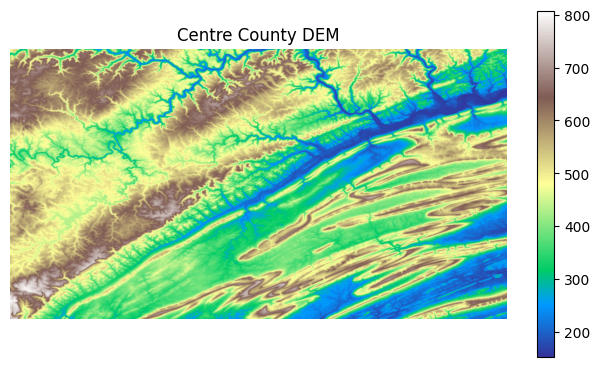

In [10]:
show_raster(dem_url, title="Centre County DEM", cmap="terrain")


## 3. Raster Agent: DEM Metadata and Cleanup

This step asks the raster agent to inspect the DEM and return a clean GeoTIFF copy with preserved CRS, transform, nodata, and data type. It is a simple first raster-agent call that confirms the raster can be loaded and saved correctly.


In [11]:
clean_dem_instructions = (
    "Inspect this DEM raster. Report its CRS, pixel size, bounds, nodata value, width, height, "
    "and elevation min/max. Then create a clean GeoTIFF copy preserving CRS, affine transform, "
    "nodata, dtype, and one elevation band. Use the raster toolkit helpers where useful."
)

clean_dem_task = None
for event in raster_agent.execute_task(
    clean_dem_instructions,
    mode="stream",
    input_datasets=[dem_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        clean_dem_task = event.get("payload")

if clean_dem_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(clean_dem_task)
clean_dem_url = first_artifact_url(clean_dem_task, preferred_extensions=[".tif", ".tiff"])
clean_dem_url


[00:56:43] stream_connected: Streaming connection established.
[00:56:44] Raster Agent: I received your request.
[00:56:44] Raster Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[00:56:44] Raster Agent: I found the required credentials and can start the model-backed workflow.
[00:56:44] task_accepted: Task accepted. Starting streaming execution.
[00:56:44] Raster Agent: Next I will run the agent with the prepared inputs.
[00:56:44] Raster Agent: I will inspect the raster or mixed raster-vector inputs, run code-driven processing, and save a final artifact from 1 dataset reference(s).
[00:56:44] Raster Agent: I am planning the next raster processing step and deciding whether to execute code or register the final artifact. This is iteration 1.
[00:56:47] Raster Agent: I will execute Python raster processing code in the sandbox to load, inspect, transform, or analyze the dataset.
[00:56:47] Raster Agen

'http://127.0.0.1:4042/agents/raster_agent/data/raster_agent-3842-ffyn-2931.tif'

## 4. Raster Agent: Hillshade

[00:57:56] stream_connected: Streaming connection established.
[00:57:57] Raster Agent: I received your request.
[00:57:57] Raster Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[00:57:57] Raster Agent: I found the required credentials and can start the model-backed workflow.
[00:57:57] task_accepted: Task accepted. Starting streaming execution.
[00:57:57] Raster Agent: Next I will run the agent with the prepared inputs.
[00:57:57] Raster Agent: I will inspect the raster or mixed raster-vector inputs, run code-driven processing, and save a final artifact from 1 dataset reference(s).
[00:57:57] Raster Agent: I am planning the next raster processing step and deciding whether to execute code or register the final artifact. This is iteration 1.
[00:58:00] Raster Agent: I will execute Python raster processing code in the sandbox to load, inspect, transform, or analyze the dataset.
[00:58:00] Raster Agen

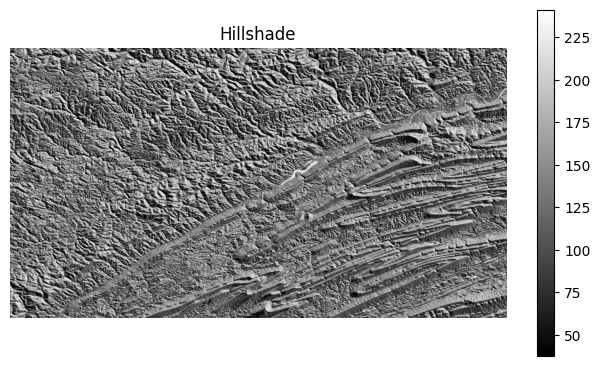

In [12]:
hillshade_instructions = (
    "Create a hillshade GeoTIFF from this DEM. Use the DEM elevation band, preserve the raster CRS "
    "and affine transform, set nodata outside valid DEM cells, and return one float32 or uint8 GeoTIFF. "
    "Use azimuth 315 degrees and altitude 45 degrees. Register the output as a georeferenced raster artifact."
)

hillshade_task = None
for event in raster_agent.execute_task(
    hillshade_instructions,
    mode="stream",
    input_datasets=[clean_dem_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        hillshade_task = event.get("payload")

if hillshade_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(hillshade_task)
hillshade_url = first_artifact_url(hillshade_task, preferred_extensions=[".tif", ".tiff"])
show_raster(hillshade_url, title="Hillshade", cmap="gray")


## 5. Raster Agent: Slope in Degrees

[00:58:12] stream_connected: Streaming connection established.
[00:58:12] Raster Agent: I received your request.
[00:58:13] Raster Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[00:58:13] Raster Agent: I found the required credentials and can start the model-backed workflow.
[00:58:13] task_accepted: Task accepted. Starting streaming execution.
[00:58:13] Raster Agent: Next I will run the agent with the prepared inputs.
[00:58:13] Raster Agent: I will inspect the raster or mixed raster-vector inputs, run code-driven processing, and save a final artifact from 1 dataset reference(s).
[00:58:13] Raster Agent: I am planning the next raster processing step and deciding whether to execute code or register the final artifact. This is iteration 1.
[00:58:17] Raster Agent: I will execute Python raster processing code in the sandbox to load, inspect, transform, or analyze the dataset.
[00:58:18] Raster Agen

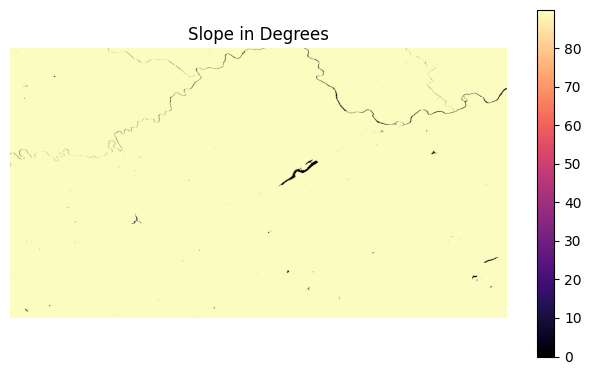

In [13]:
slope_instructions = (
    "Create a slope raster in degrees from this DEM. Use the raster pixel size from the affine transform. "
    "Preserve the source CRS and affine transform. Set nodata outside valid DEM cells. "
    "Return one georeferenced float32 GeoTIFF artifact."
)

slope_task = None
for event in raster_agent.execute_task(
    slope_instructions,
    mode="stream",
    input_datasets=[clean_dem_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        slope_task = event.get("payload")

if slope_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(slope_task)
slope_url = first_artifact_url(slope_task, preferred_extensions=[".tif", ".tiff"])
show_raster(slope_url, title="Slope in Degrees", cmap="magma")


## 6. Raster Agent: Elevation Classes

[00:58:23] stream_connected: Streaming connection established.
[00:58:23] Raster Agent: I received your request.
[00:58:23] Raster Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[00:58:23] Raster Agent: I found the required credentials and can start the model-backed workflow.
[00:58:23] task_accepted: Task accepted. Starting streaming execution.
[00:58:24] Raster Agent: Next I will run the agent with the prepared inputs.
[00:58:24] Raster Agent: I will inspect the raster or mixed raster-vector inputs, run code-driven processing, and save a final artifact from 1 dataset reference(s).
[00:58:24] Raster Agent: I am planning the next raster processing step and deciding whether to execute code or register the final artifact. This is iteration 1.
[00:58:25] Raster Agent: I will execute Python raster processing code in the sandbox to load, inspect, transform, or analyze the dataset.
[00:58:25] Raster Agen

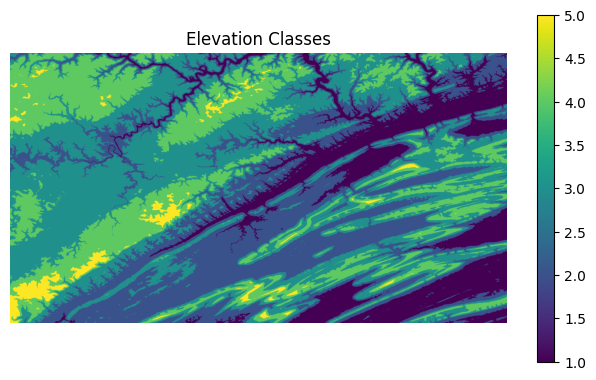

In [14]:
elevation_classes_instructions = (
    "Reclassify the DEM elevation values into 5 equal-interval elevation classes. "
    "Use class values 1 through 5 and nodata value 0. Preserve CRS and affine transform. "
    "Return one georeferenced int16 GeoTIFF artifact."
)

elevation_classes_task = None
for event in raster_agent.execute_task(
    elevation_classes_instructions,
    mode="stream",
    input_datasets=[clean_dem_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        elevation_classes_task = event.get("payload")

if elevation_classes_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(elevation_classes_task)
classes_url = first_artifact_url(elevation_classes_task, preferred_extensions=[".tif", ".tiff"])
show_raster(classes_url, title="Elevation Classes", cmap="viridis")


## 7. Raster Agent: High-Elevation Mask

[00:58:36] stream_connected: Streaming connection established.
[00:58:36] Raster Agent: I received your request.
[00:58:36] Raster Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[00:58:36] Raster Agent: I found the required credentials and can start the model-backed workflow.
[00:58:36] task_accepted: Task accepted. Starting streaming execution.
[00:58:37] Raster Agent: Next I will run the agent with the prepared inputs.
[00:58:37] Raster Agent: I will inspect the raster or mixed raster-vector inputs, run code-driven processing, and save a final artifact from 1 dataset reference(s).
[00:58:37] Raster Agent: I am planning the next raster processing step and deciding whether to execute code or register the final artifact. This is iteration 1.
[00:58:40] Raster Agent: I will execute Python raster processing code in the sandbox to load, inspect, transform, or analyze the dataset.
[00:58:40] Raster Agen

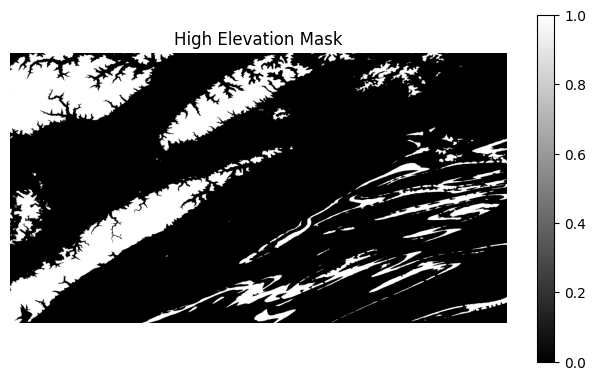

In [15]:
high_elevation_instructions = (
    "Create a binary high-elevation mask from this DEM. Mark pixels above the 80th percentile of valid elevation as 1, "
    "all other valid pixels as 0, and nodata pixels as 255. Preserve CRS and affine transform. "
    "Return one georeferenced uint8 GeoTIFF artifact."
)

high_elevation_task = None
for event in raster_agent.execute_task(
    high_elevation_instructions,
    mode="stream",
    input_datasets=[clean_dem_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client.print_stream_event(event)
    if event.get("event") == "task_result":
        high_elevation_task = event.get("payload")

if high_elevation_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client.print_task_summary(high_elevation_task)
high_elevation_url = first_artifact_url(high_elevation_task, preferred_extensions=[".tif", ".tiff"])
show_raster(high_elevation_url, title="High Elevation Mask", cmap="gray")


## Final Artifact URLs

In [16]:
all_tasks = {
    "dem_download": dem_task,
    "clean_dem": clean_dem_task,
    "hillshade": hillshade_task,
    "slope": slope_task,
    "elevation_classes": elevation_classes_task,
    "high_elevation_mask": high_elevation_task,
}

for name, task_result in all_tasks.items():
    print("\n" + name)
    for artifact in task_result.get("outputs", {}).get("artifacts", []):
        if artifact.get("url"):
            print("-", artifact.get("filename") or artifact.get("name"), artifact["url"])



dem_download
- geospatial_data_retrieval_agent-4803-pegz-6539.tif http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-4803-pegz-6539.tif

clean_dem
- raster_agent-3842-ffyn-2931.tif http://127.0.0.1:4042/agents/raster_agent/data/raster_agent-3842-ffyn-2931.tif

hillshade
- raster_agent-4856-zgoz-7604.tif http://127.0.0.1:4042/agents/raster_agent/data/raster_agent-4856-zgoz-7604.tif

slope
- raster_agent-3652-kiuu-3452.tif http://127.0.0.1:4042/agents/raster_agent/data/raster_agent-3652-kiuu-3452.tif

elevation_classes
- raster_agent-2385-gurl-1602.tif http://127.0.0.1:4042/agents/raster_agent/data/raster_agent-2385-gurl-1602.tif

high_elevation_mask
- raster_agent-0929-vdxq-8786.tif http://127.0.0.1:4042/agents/raster_agent/data/raster_agent-0929-vdxq-8786.tif
